In [23]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import SelectKBest, mutual_info_classif

RANDOM_STATE = 42
TOP_K = 10

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully.")
print("configuration: select top", TOP_K, "features")

Libraries imported successfully.
configuration: select top 10 features


## Shared prerequisite 1 — Load the official dataset

This is only data access. The official source is the [UCI Letter Recognition dataset](https://archive.ics.uci.edu/dataset/59/letter+recognition).

In [24]:
DATA_URL = "https://archive.ics.uci.edu/static/public/59/data.csv"

df_raw = pd.read_csv(DATA_URL)

print("Original dataset shape:", df_raw.shape)
display(df_raw.head())

Original dataset shape: (20000, 17)


,lettr,x-box,y-box,width,high,onpix,x-bar,y-bar,x2bar,y2bar,xybar,x2ybr,xy2br,x-ege,xegvy,y-ege,yegvx
0,T,2,8,3,5,1,8,13,0,6,6,10,8,0,8,0,8
1,I,5,12,3,7,2,10,5,5,4,13,3,9,2,8,4,10
2,D,4,11,6,8,6,10,6,2,6,10,3,7,3,7,3,9
3,N,7,11,6,6,3,5,9,4,6,4,4,10,6,10,2,8
4,G,2,1,3,1,1,8,6,6,6,6,5,9,1,7,5,10


## Shared prerequisite 2 — Use the group's cleaned data


In [25]:
df = df_raw.drop_duplicates().reset_index(drop=True)

print("Exact duplicates reported by shared setup:", df_raw.duplicated().sum())
print("Cleaned dataset shape supplied to Member 5:", df.shape)

Exact duplicates reported by shared setup: 1332
Cleaned dataset shape supplied to Member 5: (18668, 17)


## Shared prerequisite 3 — Separate inputs and encode the target

- `X` contains the 16 numerical input features.
- `y_text` contains A–Z labels.
- `y` contains the encoded target required by the feature-selection function.


In [26]:
X = df.drop(columns="lettr")
y_text = df["lettr"]
FEATURES = X.columns.tolist()

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_text)

label_mapping = dict(zip(
    label_encoder.classes_,
    label_encoder.transform(label_encoder.classes_)
))

print("Input shape received by Member 5:", X.shape)
print("Target shape received by Member 5:", y.shape)
print("Label mapping supplied by Member 2:", label_mapping)

Input shape received by Member 5: (18668, 16)
Target shape received by Member 5: (18668,)
Label mapping supplied by Member 2: {'A': np.int64(0), 'B': np.int64(1), 'C': np.int64(2), 'D': np.int64(3), 'E': np.int64(4), 'F': np.int64(5), 'G': np.int64(6), 'H': np.int64(7), 'I': np.int64(8), 'J': np.int64(9), 'K': np.int64(10), 'L': np.int64(11), 'M': np.int64(12), 'N': np.int64(13), 'O': np.int64(14), 'P': np.int64(15), 'Q': np.int64(16), 'R': np.int64(17), 'S': np.int64(18), 'T': np.int64(19), 'U': np.int64(20), 'V': np.int64(21), 'W': np.int64(22), 'X': np.int64(23), 'Y': np.int64(24), 'Z': np.int64(25)}


# 2. Required output A — Correlation heatmap

Pearson correlation measures the linear relationship between pairs of numerical input features.

- Value near `+1`: strong positive linear relationship
- Value near `-1`: strong negative linear relationship
- Value near `0`: weak linear relationship

The categorical target is not added to this heatmap. Encoding A–Z as 0–25 and calculating Pearson correlation would impose an artificial numerical order on nominal categories.

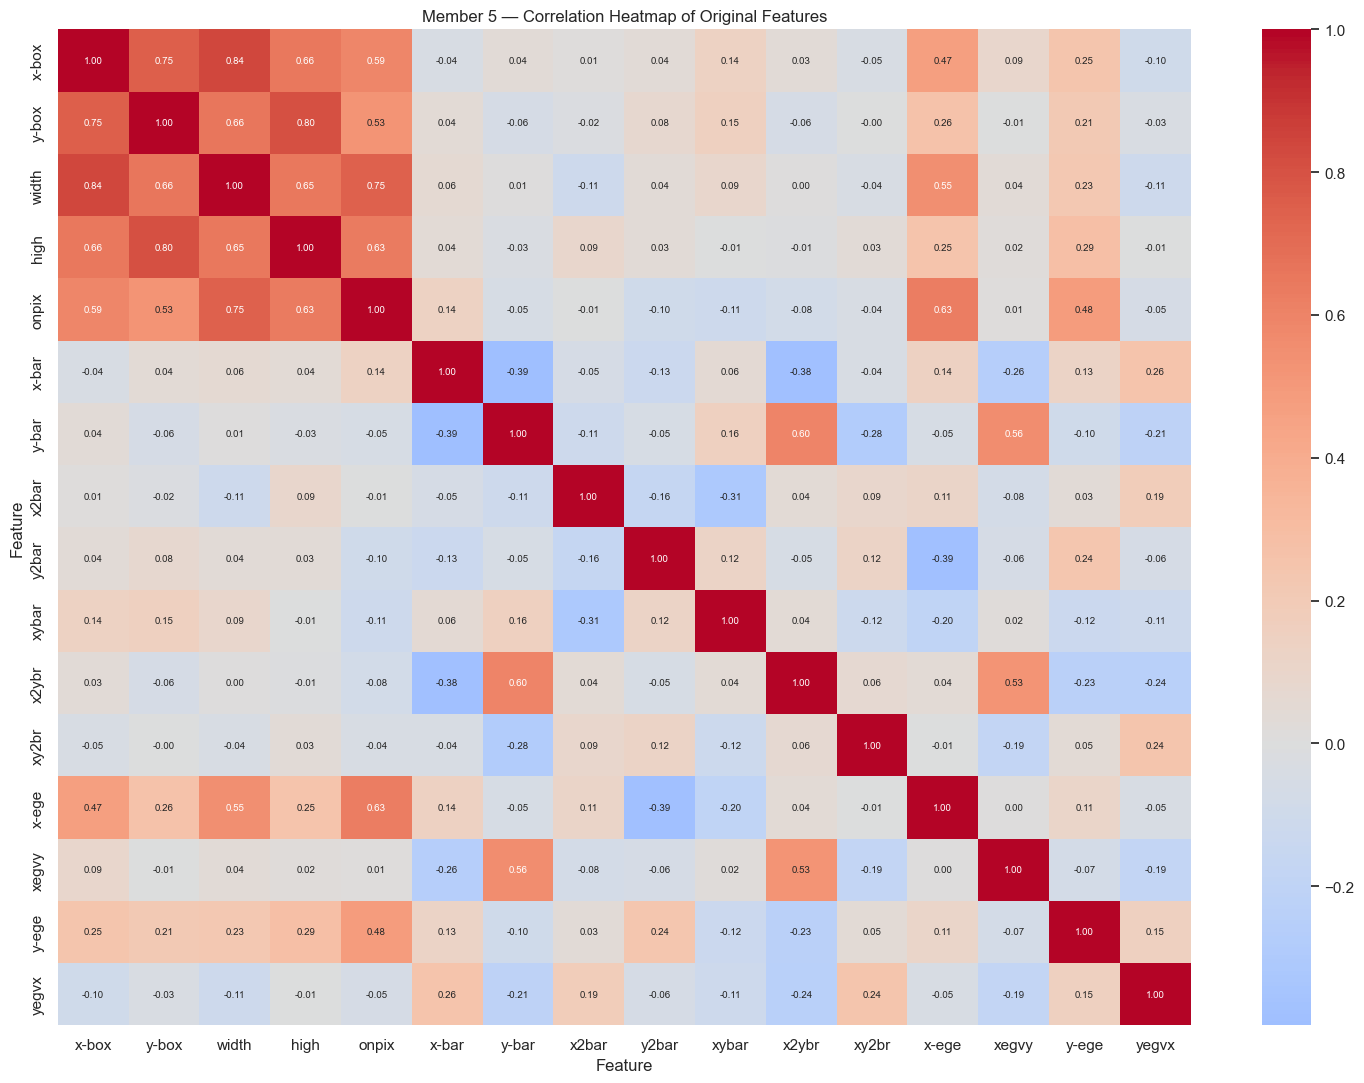

In [27]:
correlation_matrix = X.corr()

plt.figure(figsize=(15, 11))
sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 7}
)
plt.title("Member 5 — Correlation Heatmap of Original Features")
plt.xlabel("Feature")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## Strongest correlated feature pairs

The following code removes duplicate/symmetric matrix entries and ranks feature pairs by absolute correlation. This makes the heatmap easier to explain during the presentation.

In [28]:
upper_triangle = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)

correlation_pairs = (
    upper_triangle.stack()
    .rename("correlation")
    .reset_index()
    .rename(columns={"level_0": "feature_1", "level_1": "feature_2"})
)

correlation_pairs["absolute_correlation"] = (
    correlation_pairs["correlation"].abs()
)

strongest_correlations = correlation_pairs.sort_values(
    "absolute_correlation",
    ascending=False
).head(10)

display(strongest_correlations)

,feature_1,feature_2,correlation,absolute_correlation
2,x-box,width,0.838201,0.838201
19,y-box,high,0.804746,0.804746
1,x-box,y-box,0.753845,0.753845
36,width,onpix,0.747093,0.747093
18,y-box,width,0.660359,0.660359
3,x-box,high,0.656202,0.656202
35,width,high,0.647059,0.647059
52,high,onpix,0.631189,0.631189
76,onpix,x-ege,0.627043,0.627043
106,y-bar,x2ybr,0.596464,0.596464


## Heatmap interpretation

Use the actual table above in the review. The strongest pairs indicate measurements carrying related linear information. This can suggest redundancy, but correlation alone is not sufficient to delete a feature because:

- It does not measure relevance to the target letter.
- It detects only linear relationships.
- Correlated features can still provide complementary class information.

Therefore, the next step uses a target-aware method: Mutual Information.

# 3. Prevent data leakage

The data is split before fitting Mutual Information selection.

- The selector learns feature relevance from `X_train` and `y_train` only.
- The test set remains unseen during selection.
- `stratify=y` preserves the proportions of all 26 letters.

Fitting the selector on the complete dataset would leak information from the test data and produce an optimistic evaluation.

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (14934, 16)
Testing features: (3734, 16)
Training target: (14934,)
Testing target: (3734,)


# 4. Required output B — Mutual Information scores

Mutual Information estimates statistical dependency between each input feature and the target:

- Higher score: stronger detected dependency with the target
- Score near zero: little detected dependency

Unlike ordinary correlation, Mutual Information can detect nonlinear dependency. It still does not prove causation and evaluates features mainly on their individual relationships with the target.

The original 16 inputs are integer-valued discrete measurements, so `discrete_features=True` is appropriate here.

In [30]:
def calculate_mutual_information(X_values, y_values):
    return mutual_info_classif(
        X_values,
        y_values,
        discrete_features=True,
        random_state=RANDOM_STATE
    )

selector = SelectKBest(
    score_func=calculate_mutual_information,
    k=TOP_K
)

# Fit only on training data — critical for preventing leakage.
selector.fit(X_train, y_train)

print("Mutual Information selector fitted using training data only.")

Mutual Information selector fitted using training data only.


# 5. MI ranking table and selection decision

The result contains:

- `feature`: original input name
- `mutual_information`: target-dependency score
- `selected`: `True` for the top `TOP_K` features and `False` otherwise

The number `TOP_K = 10` is used to provide a clear top-feature subset for this individual demonstration. In final model development, the group should validate different values of `k` using training-only cross-validation.

In [31]:
mi_results = pd.DataFrame({
    "feature": FEATURES,
    "mutual_information": selector.scores_,
    "selected": selector.get_support()
}).sort_values(
    "mutual_information",
    ascending=False
).reset_index(drop=True)

selected_features = mi_results.loc[
    mi_results["selected"], "feature"
].tolist()

rejected_features = mi_results.loc[
    ~mi_results["selected"], "feature"
].tolist()

print("Number of original features:", len(FEATURES))
print("Number selected:", len(selected_features))
print("Selected features:", selected_features)
print("Not selected:", rejected_features)

display(mi_results)

Number of original features: 16
Number selected: 10
Selected features: ['x-ege', 'x2ybr', 'xegvy', 'y-bar', 'xy2br', 'y-ege', 'y2bar', 'x2bar', 'xybar', 'x-bar']
Not selected: ['yegvx', 'onpix', 'width', 'x-box', 'high', 'y-box']


,feature,mutual_information,selected
0,x-ege,0.609614,True
1,x2ybr,0.573033,True
2,xegvy,0.550328,True
3,y-bar,0.547160,True
4,xy2br,0.514665,True
5,y-ege,0.513733,True
6,y2bar,0.494430,True
7,x2bar,0.451731,True
8,xybar,0.395585,True
9,x-bar,0.320209,True


# 6. MI score visualization

This bar chart is Member 5's second main output:

- Green bars: selected
- Gray bars: not selected
- Longer bars: stronger Mutual Information score

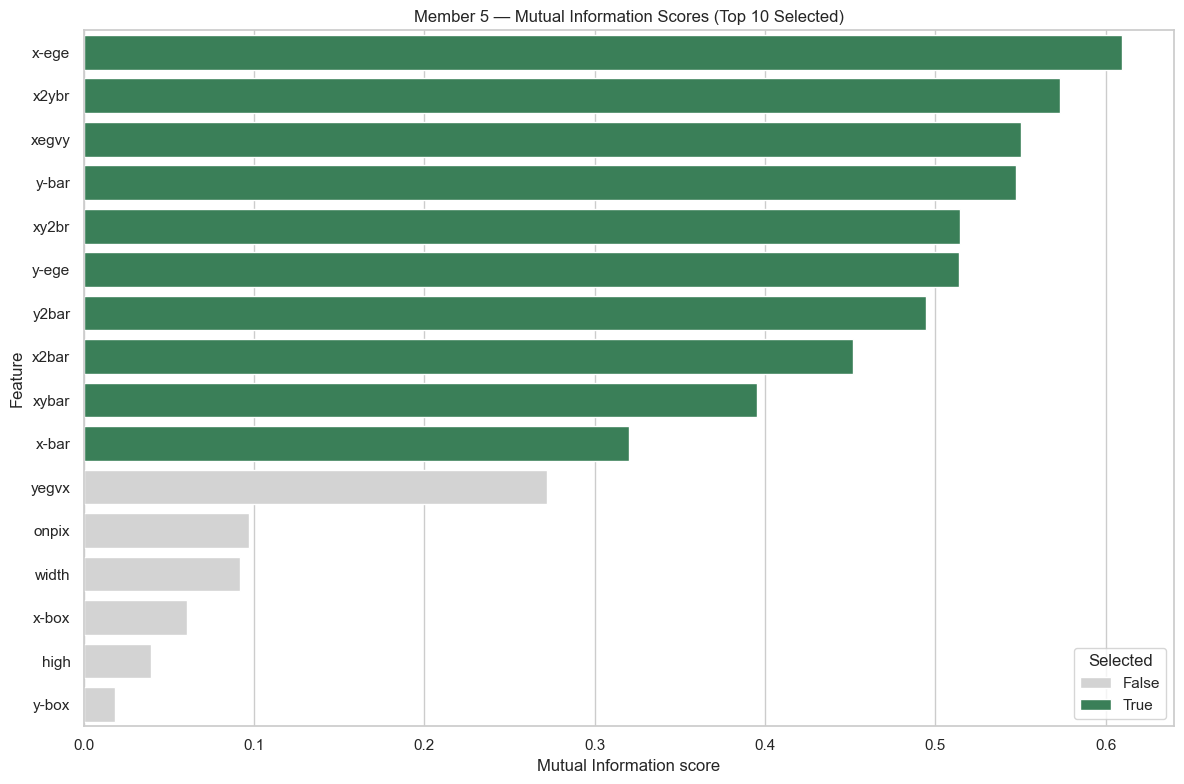

In [32]:
plt.figure(figsize=(12, 8))

sns.barplot(
    data=mi_results,
    x="mutual_information",
    y="feature",
    hue="selected",
    palette={True: "seagreen", False: "lightgray"},
    dodge=False
)

plt.title(f"Member 5 — Mutual Information Scores (Top {TOP_K} Selected)")
plt.xlabel("Mutual Information score")
plt.ylabel("Feature")
plt.legend(title="Selected")
plt.tight_layout()
plt.show()

## MI visualization interpretation

During the presentation:

1. Name the three highest-scoring features from the actual output.
2. State that they show the strongest individual dependency with the target.
3. State that green features were retained and gray features were excluded.
4. Do not claim that a rejected feature is completely useless; it may still contribute through interaction with other features.

# 7. Transform the data using selected features

`SelectKBest.transform()` converts the original train and test sets into the selected representation. The same fitted selector is applied to both sets.

In [33]:
X_train_selected_array = selector.transform(X_train)
X_test_selected_array = selector.transform(X_test)

selected_columns_in_transform_order = X_train.columns[
    selector.get_support()
].tolist()

X_train_selected = pd.DataFrame(
    X_train_selected_array,
    columns=selected_columns_in_transform_order,
    index=X_train.index
)

X_test_selected = pd.DataFrame(
    X_test_selected_array,
    columns=selected_columns_in_transform_order,
    index=X_test.index
)

print("Before selection — training shape:", X_train.shape)
print("After selection — training shape:", X_train_selected.shape)
print("Before selection — testing shape:", X_test.shape)
print("After selection — testing shape:", X_test_selected.shape)

display(X_train_selected.head())

Before selection — training shape: (14934, 16)
After selection — training shape: (14934, 10)
Before selection — testing shape: (3734, 16)
After selection — testing shape: (3734, 10)


,x-bar,y-bar,x2bar,y2bar,xybar,x2ybr,xy2br,x-ege,xegvy,y-ege
13685,3,8,5,8,11,10,13,1,9,3
7436,10,4,4,7,11,2,7,3,7,5
6350,9,6,3,5,10,4,7,3,6,4
6373,7,7,14,2,5,6,8,6,8,0
11511,7,7,4,4,6,5,8,8,7,2


## Important handoff to the group

Member 5 supplies:

- `selected_features`
- `X_train_selected`
- `X_test_selected`
- The MI ranking table

Member 3 may apply scaling if the selected model requires it. Model-development members can compare the selected representation with the complete feature set. Member 5 does not claim that the top-10 subset is automatically the final best input until model evaluation confirms it.